# GNN Training for Network Anomaly Prediction

This notebook contains the complete pipeline for training Graph Neural Networks on network telemetry data to predict anomalies.

## Contents
1. [Setup & Dependencies](#setup)
2. [Dataset Loading](#dataset)
3. [Model Architecture](#model)
4. [Training](#training)
5. [Evaluation](#evaluation)
6. [Inference](#inference)
7. [Visualization](#viz)

In [80]:
!pip install seaborn matplotlib scikit-learn tqdm
!pip install --upgrade numpy seaborn

import json
import os
import sys
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Optional, Tuple
import numpy as np
# Check if torch is available, if not install it
try:
    import torch
    print(f"Ã¢ÂÂ PyTorch {torch.__version__} already installed")
except ImportError:
    print("PyTorch not found. Installing...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "--index-url", "https://download.pytorch.org/whl/cpu", "--no-cache-dir", "--quiet"])
    import torch
    print(f"Ã¢ÂÂ PyTorch {torch.__version__} installed")
# Check torch_geometric
try:
    import torch_geometric
    print(f"Ã¢ÂÂ PyTorch Geometric {torch_geometric.__version__} already installed")
except ImportError:
    print("PyTorch Geometric not found. Installing...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch-geometric", "--no-cache-dir", "--quiet"])
    import torch_geometric
    print(f"Ã¢ÂÂ PyTorch Geometric {torch_geometric.__version__} installed")
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset
from torch_geometric.data import Batch, Data
from torch_geometric.nn import GATConv
from tqdm import tqdm
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
# Set random seeds
torch.manual_seed(42)
np.random.seed(42)
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


DEPRECATION: Python 2.7 reached the end of its life on January 1st, 2020. Please upgrade your Python as Python 2.7 is no longer maintained. pip 21.0 will drop support for Python 2.7 in January 2021. More details about Python 2 support in pip can be found at https://pip.pypa.io/en/latest/development/release-process/#python-2-support pip 21.0 will remove support for this functionality.
Defaulting to user installation because normal site-packages is not writeable
DEPRECATION: Python 2.7 reached the end of its life on January 1st, 2020. Please upgrade your Python as Python 2.7 is no longer maintained. pip 21.0 will drop support for Python 2.7 in January 2021. More details about Python 2 support in pip can be found at https://pip.pypa.io/en/latest/development/release-process/#python-2-support pip 21.0 will remove support for this functionality.
Defaulting to user installation because normal site-packages is not writeable
Requirement already up-to-date: numpy in /home/mininet/.local/lib/pyth

In [81]:
import json
import os
import sys
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Optional, Tuple
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset
from torch_geometric.data import Batch, Data
from torch_geometric.nn import GATConv
from tqdm import tqdm
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
# Set random seeds
torch.manual_seed(42)
np.random.seed(42)
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


## 2. Dataset Loading <a name="dataset"></a>

Define the PyTorch Geometric dataset for loading JSON snapshots:

In [82]:
# Define Predictive Merged Labels
MERGED_LABEL_MAP = {
    "NORMAL": "NORMAL",
    "RECOVERY": "NORMAL",
    "CONGESTION_BUILDUP": "CONGESTION",
    "CONGESTION_ACTIVE": "CONGESTION",
    "LATENCY_DEGRADING": "LATENCY",
    "LATENCY_CRITICAL": "LATENCY",
    "PACKET_LOSS_MILD": "PACKET_LOSS",
    "PACKET_LOSS_SEVERE": "PACKET_LOSS",
    "JITTER_HIGH": "JITTER",
    "BANDWIDTH_THROTTLED": "BANDWIDTH",
    "BROWNOUT": "INFRA_FAILURE",
    "LINK_FAILURE": "INFRA_FAILURE",
    "DDOS_BUILDUP": "DDOS",
    "DDOS_ACTIVE": "DDOS",
    "DDOS_SOURCE": "DDOS",
    "DDOS_TARGET": "DDOS",
    "PORTSCAN_RECON": "SCANNING",
    "BRUTE_FORCE_PROBE": "BRUTE_FORCE",
    "BRUTE_FORCE_ACTIVE": "BRUTE_FORCE",
    "LATERAL_MOVEMENT": "SCANNING",  # Merged with SCANNING (both are recon/exploitation)
    "EXFILTRATION": "SCANNING"  # Merged with SCANNING
}

def get_merged_label_info(original_metadata):
    """Compute new label mapping based on merged classes."""
    orig_label_to_index = original_metadata["label_to_index"]
    
    unique_merged = sorted(list(set(MERGED_LABEL_MAP.values())))
    # Ensure NORMAL is index 0
    if "NORMAL" in unique_merged:
        unique_merged.remove("NORMAL")
        unique_merged = ["NORMAL"] + unique_merged
        
    new_label_to_index = {name: i for i, name in enumerate(unique_merged)}
    
    # Map original index -> new index
    mapping = {}
    for orig_name, orig_idx in orig_label_to_index.items():
        new_name = MERGED_LABEL_MAP.get(orig_name, "NORMAL")
        mapping[orig_idx] = new_label_to_index[new_name]
        
    return new_label_to_index, mapping

class NetworkGNNDataset(Dataset):
    """Dataset for network telemetry graph snapshots."""
    
    def __init__(
        self,
        data_dir: str,
        horizon: str = "horizon_30s",
        node_feature_dim: int = 14,
        edge_feature_dim: int = 6,
        seq_len: int = 5,
    ):
        self.data_dir = Path(data_dir)
        self.horizon = horizon
        self.node_feature_dim = node_feature_dim
        self.edge_feature_dim = edge_feature_dim
        self.seq_len = seq_len
        from sklearn.preprocessing import StandardScaler
        self.scaler = StandardScaler()
        
        # Load metadata
        with open(self.data_dir / "metadata.json", "r") as f:
            self.metadata = json.load(f)
        
        self.num_nodes = len(self.metadata["node_names"])
        self.label_to_index = self.metadata["label_to_index"]
        self.index_to_label = {v: k for k, v in self.label_to_index.items()}
        self.merged_label_to_index, self.index_mapping = get_merged_label_info(self.metadata)
        self.num_classes = len(self.merged_label_to_index)
        self.index_to_label = {v: k for k, v in self.merged_label_to_index.items()}
        
        # Build edge index
        self.edge_index = self._build_edge_index()
        self._fit_scaler()
        
        # Get snapshot files
        snap_dir = self.data_dir / "snapshots"
        self.snapshot_files = sorted(
            [f for f in snap_dir.glob("window_*.json")],
            key=lambda x: int(x.stem.split("_")[1])
        )
        
        if len(self.snapshot_files) < seq_len:
            raise ValueError(f"Need at least {seq_len} snapshots, got {len(self.snapshot_files)}")
        
        self.num_sequences = len(self.snapshot_files) - seq_len + 1
    
    def _fit_scaler(self):
        print("Fitting feature scaler...")
        all_features = []
        snap_dir = self.data_dir / "snapshots"
        snap_files = sorted([f for f in snap_dir.glob("window_*.json")], key=lambda x: int(x.stem.split("_")[1]))
        for snap_file in snap_files:
            snap = self._load_snapshot(snap_file)
            all_features.append(snap["node_features"])
        import numpy as np
        all_features_np = np.array(all_features).reshape(-1, self.node_feature_dim)
        self.scaler.fit(all_features_np)
        print("Scaler fitted.")

    def _build_edge_index(self) -> torch.Tensor:
        """Build edge index from topology."""
        edges = self.metadata.get("edges", [])
        node_index = self.metadata["node_index"]
        
        edge_pairs = []
        for src_name, dst_name in edges:
            if src_name in node_index and dst_name in node_index:
                edge_pairs.append([node_index[src_name], node_index[dst_name]])
                edge_pairs.append([node_index[dst_name], node_index[src_name]])
        
        if not edge_pairs:
            for i in range(self.num_nodes):
                for j in range(self.num_nodes):
                    if i != j:
                        edge_pairs.append([i, j])
        
        return torch.tensor(edge_pairs, dtype=torch.long).t().contiguous()
    
    def _load_snapshot(self, file_path: Path) -> Dict:
        with open(file_path, "r") as f:
            return json.load(f)
    
    def __len__(self) -> int:
        return self.num_sequences
    
    def __getitem__(self, idx: int) -> Data:
        # Load sequence
        seq_snapshots = []
        for i in range(self.seq_len):
            snap_file = self.snapshot_files[idx + i]
            seq_snapshots.append(self._load_snapshot(snap_file))
        
        # Build features
        node_features_seq = []
        for snap in seq_snapshots:
            node_feats_np = np.array(snap["node_features"])
            node_feats_scaled = self.scaler.transform(node_feats_np)
            node_feats = torch.tensor(node_feats_scaled, dtype=torch.float)
            node_features_seq.append(node_feats)
        
        node_features = torch.stack(node_features_seq, dim=0)
        node_features = node_features.transpose(0, 1)  # [num_nodes, seq_len, features]
        
        last_snap = seq_snapshots[-1]
        edge_features = torch.tensor(last_snap.get("edge_features", []), dtype=torch.float)
        
        if edge_features.shape[0] == 0:
            num_edges = self.edge_index.shape[1]
            edge_features = torch.zeros(num_edges, self.edge_feature_dim)
        
        pred_labels = last_snap.get("prediction_labels", {}).get(self.horizon, {})
        
        node_label_indices = pred_labels.get("node_indices", [0] * self.num_nodes)
        y_orig = torch.tensor(node_label_indices, dtype=torch.long)
        y = torch.tensor([self.index_mapping[idx.item()] for idx in y_orig], dtype=torch.long)
        
        window_label_idx = pred_labels.get("window_index", 0)
        y_window_orig = window_label_idx
        y_window = torch.tensor([self.index_mapping[y_window_orig]], dtype=torch.long)
        
        current_labels = last_snap.get("current_labels", {})
        y_current = torch.tensor(
            current_labels.get("node_indices", [0] * self.num_nodes),
            dtype=torch.long
        )
        
        return Data(
            x=node_features,
            edge_index=self.edge_index,
            edge_attr=edge_features,
            y=y,
            y_window=y_window,
            y_current=y_current,
            window_idx=idx,
        )
    
    def split(self, train_ratio=0.7, val_ratio=0.15):
        """Split dataset."""
        total = len(self)
        train_size = int(total * train_ratio)
        val_size = int(total * val_ratio)
        
        indices = list(range(total))
        np.random.shuffle(indices)
        
        train_idx = indices[:train_size]
        val_idx = indices[train_size:train_size + val_size]
        test_idx = indices[train_size + val_size:]
        
        return (
            SubsetDataset(self, train_idx),
            SubsetDataset(self, val_idx),
            SubsetDataset(self, test_idx),
        )
class SubsetDataset(Dataset):
    """Subset wrapper."""
    def __init__(self, dataset: NetworkGNNDataset, indices: List[int]):
        self.dataset = dataset
        self.indices = indices
        self.num_classes = dataset.num_classes
        self.label_to_index = dataset.label_to_index
        self.index_to_label = dataset.index_to_label
        self.metadata = dataset.metadata
        self.num_nodes = dataset.num_nodes
    
    def __len__(self) -> int:
        return len(self.indices)
    
    def __getitem__(self, idx: int) -> Data:
        return self.dataset[self.indices[idx]]
def collate_fn(batch):
    """Collate function for batching."""
    return Batch.from_data_list(batch)
# Test dataset loading
DATA_DIR = "data/gnn_datasets/gnn_20260508_173048"
dataset = NetworkGNNDataset(DATA_DIR, horizon="horizon_30s", seq_len=5)
print(f"Dataset loaded: {len(dataset)} sequences")
print(f"Nodes: {dataset.num_nodes}, Classes: {dataset.num_classes}")
sample = dataset[0]
print(f"\nSample shape: x={sample.x.shape}, edge_index={sample.edge_index.shape}")


Fitting feature scaler...


Scaler fitted.
Dataset loaded: 1057 sequences
Nodes: 26, Classes: 10

Sample shape: x=torch.Size([26, 5, 14]), edge_index=torch.Size([2, 650])


## 3. Model Architecture <a name="model"></a>

Define the Temporal Graph Attention Network:

In [83]:
class TemporalGAT(nn.Module):
    """Temporal Graph Attention Network."""
    
    def __init__(
        self,
        node_feature_dim: int = 14,
        hidden_dim: int = 128,
        num_classes: int = 21,
        seq_len: int = 5,
        num_gat_layers: int = 3,
        num_heads: int = 4,
        dropout: float = 0.3,
    ):
        super().__init__()
        
        self.node_feature_dim = node_feature_dim
        self.hidden_dim = hidden_dim
        self.num_classes = num_classes
        self.seq_len = seq_len
        self.dropout = dropout
        
        # Temporal encoder
        self.temporal_encoder = nn.LSTM(
            input_size=node_feature_dim,
            hidden_size=hidden_dim // 2,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if seq_len > 1 else 0,
        )
        
        # GAT layers
        self.gat_layers = nn.ModuleList()
        
        self.gat_layers.append(
            GATConv(
                in_channels=hidden_dim,
                out_channels=hidden_dim // num_heads,
                heads=num_heads,
                dropout=dropout,
                concat=True,
            )
        )
        
        for _ in range(num_gat_layers - 2):
            self.gat_layers.append(
                GATConv(
                    in_channels=hidden_dim,
                    out_channels=hidden_dim // num_heads,
                    heads=num_heads,
                    dropout=dropout,
                    concat=True,
                )
            )
        
        self.gat_layers.append(
            GATConv(
                in_channels=hidden_dim,
                out_channels=hidden_dim,
                heads=1,
                dropout=dropout,
                concat=False,
            )
        )
        
        self.layer_norms = nn.ModuleList([
            nn.LayerNorm(hidden_dim) for _ in range(num_gat_layers)
        ])
        
        # Classifiers
        self.node_classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes),
        )
        
        self.graph_pool = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        
        self.window_classifier = nn.Sequential(
            nn.Linear(hidden_dim // 2 + num_classes, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes),
        )
    
    def forward(self, data: Data):
        x, edge_index = data.x, data.edge_index
        batch = data.batch if hasattr(data, 'batch') else None
        
        if batch is not None:
            return self.forward_batch(data)
        
        # Single graph
        num_nodes = x.shape[0]
        
        # Temporal encoding
        x_flat = x.view(-1, self.seq_len, self.node_feature_dim)
        lstm_out, _ = self.temporal_encoder(x_flat)
        x_encoded = lstm_out[:, -1, :]
        
        # GAT layers
        h = x_encoded
        for gat, norm in zip(self.gat_layers, self.layer_norms):
            h_new = gat(h, edge_index)
            h_new = F.elu(h_new)
            h_new = norm(h_new)
            h_new = F.dropout(h_new, p=self.dropout, training=self.training)
            
            if h.shape == h_new.shape:
                h = h + h_new
            else:
                h = h_new
        
        # Classification
        node_logits = self.node_classifier(h)
        
        h_pooled = self.graph_pool(h)
        h_max = torch.max(h_pooled, dim=0)[0]
        h_mean = torch.mean(h_pooled, dim=0)
        h_graph = (h_max + h_mean) / 2
        
        node_probs = F.softmax(node_logits, dim=-1)
        max_node_pred = torch.max(node_probs, dim=0)[0]
        
        window_input = torch.cat([h_graph, max_node_pred], dim=0).unsqueeze(0)
        window_logits = self.window_classifier(window_input)
        
        return node_logits, window_logits
    
    def forward_batch(self, data: Data):
        """Batch forward."""
        x, edge_index, batch = data.x, data.edge_index, data.batch
        
        num_graphs = batch.max().item() + 1
        num_nodes_per_graph = x.shape[0] // num_graphs
        
        x_reshaped = x.view(num_graphs * num_nodes_per_graph, self.seq_len, self.node_feature_dim)
        
        lstm_out, _ = self.temporal_encoder(x_reshaped)
        x_encoded = lstm_out[:, -1, :]
        
        h = x_encoded
        for gat, norm in zip(self.gat_layers, self.layer_norms):
            h_new = gat(h, edge_index)
            h_new = F.elu(h_new)
            h_new = norm(h_new)
            h_new = F.dropout(h_new, p=self.dropout, training=self.training)
            if h.shape == h_new.shape:
                h = h + h_new
            else:
                h = h_new
        
        node_logits = self.node_classifier(h)
        h_pooled = self.graph_pool(h)
        
        # Aggregate per graph
        h_graph_max = torch.zeros(num_graphs, h_pooled.shape[1], device=h.device)
        h_graph_mean = torch.zeros(num_graphs, h_pooled.shape[1], device=h.device)
        
        for i in range(num_graphs):
            mask = (batch == i)
            h_graph_max[i] = torch.max(h_pooled[mask], dim=0)[0]
            h_graph_mean[i] = torch.mean(h_pooled[mask], dim=0)
        
        h_graph = (h_graph_max + h_graph_mean) / 2
        
        max_node_pred = torch.zeros(num_graphs, self.num_classes, device=h.device)
        for i in range(num_graphs):
            mask = (batch == i)
            node_probs = F.softmax(node_logits[mask], dim=-1)
            max_node_pred[i] = torch.max(node_probs, dim=0)[0]
        
        window_input = torch.cat([h_graph, max_node_pred], dim=-1)
        window_logits = self.window_classifier(window_input)
        
        return node_logits, window_logits
# Test model
model = TemporalGAT(
    node_feature_dim=14,
    num_classes=21,
    seq_len=5,
    hidden_dim=64,
).to(device)
sample = dataset[0].to(device)
node_logits, window_logits = model(sample)
print(f"Model test passed!")
print(f"Node logits: {node_logits.shape}")
print(f"Window logits: {window_logits.shape}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")


Model test passed!
Node logits: torch.Size([26, 21])
Window logits: torch.Size([1, 21])
Parameters: 57,898


## 4. Training <a name="training"></a>

Configure and run training:

In [84]:
# Training Configuration
CONFIG = {
    "data_dir": "data/gnn_datasets/gnn_20260508_173048",
    "horizon": "horizon_30s",
    "seq_len": 5,
    "hidden_dim": 256,
    "num_gat_layers": 3,
    "num_heads": 4,
    "dropout": 0.3,
    "batch_size": 16,
    "epochs": 300,
    "lr": 0.0005,
    "weight_decay": 1e-5,
    "train_ratio": 0.7,
    "val_ratio": 0.15,
    "use_class_weights": True,
    "node_loss_weight": 1.0,
    "window_loss_weight": 0.5,
}
print("Training Configuration:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")


Training Configuration:
  data_dir: data/gnn_datasets/gnn_20260508_173048
  horizon: horizon_30s
  seq_len: 5
  hidden_dim: 256
  num_gat_layers: 3
  num_heads: 4
  dropout: 0.3
  batch_size: 16
  epochs: 300
  lr: 0.0005
  weight_decay: 1e-05
  train_ratio: 0.7
  val_ratio: 0.15
  use_class_weights: True
  node_loss_weight: 1.0
  window_loss_weight: 0.5


In [85]:
# Load and split dataset
dataset = NetworkGNNDataset(
    data_dir=CONFIG["data_dir"],
    horizon=CONFIG["horizon"],
    seq_len=CONFIG["seq_len"],
)
train_dataset, val_dataset, test_dataset = dataset.split(
    train_ratio=CONFIG["train_ratio"],
    val_ratio=CONFIG["val_ratio"]
)
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# Create WeightedRandomSampler for imbalance
train_labels = []
for data in train_dataset:
    train_labels.append(data.y_window[0].item())  # Use window label, not first node label

unique, counts = np.unique(train_labels, return_counts=True)
class_weights = np.zeros(dataset.num_classes)
for u, c in zip(unique, counts):
    class_weights[u] = 1.0 / c
sample_weights = np.array([class_weights[t] for t in train_labels])
sampler = torch.utils.data.WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    sampler=sampler,
    collate_fn=collate_fn,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    collate_fn=collate_fn,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    collate_fn=collate_fn,
)


Fitting feature scaler...
Scaler fitted.
Train: 739, Val: 158, Test: 160


In [86]:
# Training Configuration
CONFIG = {
    "data_dir": "data/gnn_datasets/gnn_20260508_173048",
    "horizon": "horizon_30s",
    "seq_len": 5,
    "hidden_dim": 256,
    "num_gat_layers": 3,
    "num_heads": 4,
    "dropout": 0.3,
    "batch_size": 16,
    "epochs": 300,
    "lr": 0.0005,
    "weight_decay": 1e-5,
    "train_ratio": 0.7,
    "val_ratio": 0.15,
    "use_class_weights": True,
    "node_loss_weight": 1.0,
    "window_loss_weight": 0.5,
}
print("Training Configuration:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")


Training Configuration:
  data_dir: data/gnn_datasets/gnn_20260508_173048
  horizon: horizon_30s
  seq_len: 5
  hidden_dim: 256
  num_gat_layers: 3
  num_heads: 4
  dropout: 0.3
  batch_size: 16
  epochs: 300
  lr: 0.0005
  weight_decay: 1e-05
  train_ratio: 0.7
  val_ratio: 0.15
  use_class_weights: True
  node_loss_weight: 1.0
  window_loss_weight: 0.5


In [87]:
# Initialize model
model = TemporalGAT(
    node_feature_dim=14,
    num_classes=dataset.num_classes,
    seq_len=CONFIG["seq_len"],
    hidden_dim=CONFIG["hidden_dim"],
    num_gat_layers=CONFIG["num_gat_layers"],
    num_heads=CONFIG["num_heads"],
    dropout=CONFIG["dropout"],
).to(device)
optimizer = AdamW(
    model.parameters(),
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"],
)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=10)
print(f"Model initialized with {sum(p.numel() for p in model.parameters()):,} parameters")


Model initialized with 829,332 parameters


In [88]:
print("Computing smoothed class weights...")
train_labels = []
for batch in train_loader:
    train_labels.extend(batch.y.cpu().numpy())
    
unique, counts = np.unique(train_labels, return_counts=True)
weights = np.zeros(dataset.num_classes)
for i, count in zip(unique, counts):
    weights[i] = np.sqrt(len(train_labels) / count)
    
weights = weights / np.sum(weights) * dataset.num_classes
class_weights = torch.tensor(weights, dtype=torch.float).to(device)
print("Smoothed class weights computed.")


Computing smoothed class weights...
Smoothed class weights computed.


In [89]:
# Training functions
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    node_correct = 0
    window_correct = 0
    total_nodes = 0
    total_graphs = 0
    all_preds = []
    all_labels = []
    
    for batch in tqdm(loader, desc="Training"):
        batch = batch.to(device)
        
        optimizer.zero_grad()
        node_logits, window_logits = model(batch)
        
        # Losses - use Focal Loss for node classification
        if class_weights is not None:
            node_loss = F.cross_entropy(node_logits, batch.y, weight=class_weights)
        else:
            node_loss = F.cross_entropy(node_logits, batch.y)
        window_loss = F.cross_entropy(window_logits, batch.y_window)
        loss = CONFIG["node_loss_weight"] * node_loss + CONFIG["window_loss_weight"] * window_loss
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # Metrics
        total_loss += loss.item()
        node_pred = node_logits.argmax(dim=-1)
        node_correct += (node_pred == batch.y).sum().item()
        total_nodes += batch.y.shape[0]
        
        window_pred = window_logits.argmax(dim=-1)
        window_correct += (window_pred == batch.y_window).sum().item()
        total_graphs += batch.y_window.shape[0]
        
        all_preds.extend(node_pred.cpu().numpy())
        all_labels.extend(batch.y.cpu().numpy())
    
    return {
        "loss": total_loss / len(loader),
        "node_acc": node_correct / total_nodes,
        "window_acc": window_correct / total_graphs,
        "macro_f1": f1_score(all_labels, all_preds, average="macro", zero_division=0),
    }

@torch.no_grad()
def eval_epoch(model, loader, device):
    model.eval()
    total_loss = 0
    node_correct = 0
    window_correct = 0
    total_nodes = 0
    total_graphs = 0
    all_preds = []
    all_labels = []
    
    for batch in tqdm(loader, desc="Evaluating"):
        batch = batch.to(device)
        
        node_logits, window_logits = model(batch)
        
        if class_weights is not None:
            node_loss = F.cross_entropy(node_logits, batch.y, weight=class_weights)
        else:
            node_loss = F.cross_entropy(node_logits, batch.y)
        window_loss = F.cross_entropy(window_logits, batch.y_window)
        loss = CONFIG["node_loss_weight"] * node_loss + CONFIG["window_loss_weight"] * window_loss
        
        total_loss += loss.item()
        
        node_pred = node_logits.argmax(dim=-1)
        node_correct += (node_pred == batch.y).sum().item()
        total_nodes += batch.y.shape[0]
        
        window_pred = window_logits.argmax(dim=-1)
        window_correct += (window_pred == batch.y_window).sum().item()
        total_graphs += batch.y_window.shape[0]
        
        all_preds.extend(node_pred.cpu().numpy())
        all_labels.extend(batch.y.cpu().numpy())
    
    return {
        "loss": total_loss / len(loader),
        "node_acc": node_correct / total_nodes,
        "window_acc": window_correct / total_graphs,
        "macro_f1": f1_score(all_labels, all_preds, average="macro", zero_division=0),
        "preds": np.array(all_preds),
        "labels": np.array(all_labels),
    }


In [90]:
# Training Loop
history = []
best_val_f1 = 0.0
best_val_loss = float('inf')
patience_counter = 0
print(f"\n{'='*60}")
print(f"Starting Training: {CONFIG['epochs']} epochs")
print(f"{'='*60}")
for epoch in range(1, CONFIG["epochs"] + 1):
    print(f"\nEpoch {epoch}/{CONFIG['epochs']}")
    print("-" * 40)
    
    # Train
    train_metrics = train_epoch(model, train_loader, optimizer, device)
    print(f"Train - Loss: {train_metrics['loss']:.4f}, "
          f"Node Acc: {train_metrics['node_acc']:.4f}, "
          f"Window Acc: {train_metrics['window_acc']:.4f}")
    
    # Validate
    val_metrics = eval_epoch(model, val_loader, device)
    print(f"Val   - Loss: {val_metrics['loss']:.4f}, "
          f"Node Acc: {val_metrics['node_acc']:.4f}, "
          f"Window Acc: {val_metrics['window_acc']:.4f}")
    
    # Update scheduler
    scheduler.step(val_metrics["loss"])
    
    # Save history
    history.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_node_acc": train_metrics["node_acc"],
        "train_window_acc": train_metrics["window_acc"],
        "val_loss": val_metrics["loss"],
        "val_node_acc": val_metrics["node_acc"],
        "val_window_acc": val_metrics["window_acc"],
    })
    
    # Save best model
    if val_metrics["loss"] < best_val_loss:
        best_val_f1 = val_metrics["macro_f1"]
        best_val_loss = val_metrics["loss"]
        best_val_f1 = val_metrics["macro_f1"]
        patience_counter = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "config": CONFIG,
            "val_macro_f1": best_val_f1,
            "best_val_loss": best_val_loss,
        }, "best_model.pt")
        print(f"  Ã¢ÂÂ Saved best model (F1: {best_val_f1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= 30:
            print(f"\nEarly stopping triggered at epoch {epoch}. No improvement in Val Loss for 30 epochs.")
            break
print(f"\n{'='*60}")
print(f"Training Complete!")
print(f"{'='*60}")



Starting Training: 300 epochs

Epoch 1/300
----------------------------------------


Training: 100%|██████████| 47/47 [00:08<00:00,  5.41it/s]


Train - Loss: 2.4607, Node Acc: 0.8363, Window Acc: 0.2436


Evaluating: 100%|██████████| 10/10 [00:00<00:00, 12.72it/s]


Val   - Loss: 1.8524, Node Acc: 0.8868, Window Acc: 0.5380
  Ã¢ÂÂ Saved best model (F1: 0.1985)

Epoch 2/300
----------------------------------------


...

Val   - Loss: 0.5888, Node Acc: 0.9652, Window Acc: 0.8228

Epoch 156/300
----------------------------------------


Training: 100%|██████████| 47/47 [00:08<00:00,  5.86it/s]


Train - Loss: 0.4657, Node Acc: 0.9722, Window Acc: 0.8471


Evaluating: 100%|██████████| 10/10 [00:00<00:00, 12.29it/s]

Val   - Loss: 0.5903, Node Acc: 0.9659, Window Acc: 0.8354

Early stopping triggered at epoch 156. No improvement in Val Loss for 30 epochs.

Training Complete!


## 5. Evaluation <a name="evaluation"></a>

Evaluate the trained model on test data:

In [91]:
# Load best model
checkpoint = torch.load("best_model.pt", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
best_val_loss = checkpoint.get("best_val_loss", checkpoint.get("val_loss", 0.0))
print(f"Loaded best model from epoch {checkpoint['epoch']}")
# Test evaluation
test_metrics = eval_epoch(model, test_loader, device)
print(f"\n{'='*60}")
print(f"Test Results")
print(f"{'='*60}")
print(f"Loss: {test_metrics['loss']:.4f}")
print(f"Node Accuracy: {test_metrics['node_acc']:.4f}")
print(f"Window Accuracy: {test_metrics['window_acc']:.4f}")
# F1 scores
macro_f1 = f1_score(test_metrics["labels"], test_metrics["preds"], average="macro", zero_division=0)
weighted_f1 = f1_score(test_metrics["labels"], test_metrics["preds"], average="weighted", zero_division=0)
print(f"\nNode-level F1 Scores:")
print(f"  Macro F1: {macro_f1:.4f}")
print(f"  Weighted F1: {weighted_f1:.4f}")


/tmp/ipykernel_2035/3812599301.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("best_model.pt", map_location=device)


Loaded best model from epoch 126


Evaluating: 100%|██████████| 10/10 [00:00<00:00, 13.52it/s]



Test Results
Loss: 0.5100
Node Accuracy: 0.9692
Window Accuracy: 0.8562

Node-level F1 Scores:
  Macro F1: 0.8445
  Weighted F1: 0.9709


In [92]:
# Detailed per-class metrics
unique_labels = sorted(set(test_metrics["labels"]))
precision, recall, f1, support = precision_recall_fscore_support(
    test_metrics["labels"], test_metrics["preds"], labels=unique_labels, average=None, zero_division=0
)
print(f"\n{'='*60}")
print(f"Per-Class Performance")
print(f"{'='*60}")
print(f"{'Class':<25} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
print("-" * 75)
for i, idx in enumerate(unique_labels):
    label_name = dataset.index_to_label.get(idx, f"Class_{idx}")
    print(f"{label_name:<25} {precision[i]:>10.4f} {recall[i]:>10.4f} {f1[i]:>10.4f} {int(support[i]):>10}")



Per-Class Performance
Class                      Precision     Recall         F1    Support
---------------------------------------------------------------------------
NORMAL                        0.9915     0.9766     0.9840       3838
BRUTE_FORCE                   0.5534     0.9048     0.6867         63
CONGESTION                    0.7717     0.8875     0.8256         80
DDOS                          0.8226     0.8947     0.8571         57
INFRA_FAILURE                 0.8929     0.9259     0.9091         27
JITTER                        1.0000     0.5714     0.7273          7
LATENCY                       0.8400     0.8750     0.8571         24
PACKET_LOSS                   0.9375     0.9375     0.9375         16
SCANNING                      0.8000     0.8333     0.8163         48


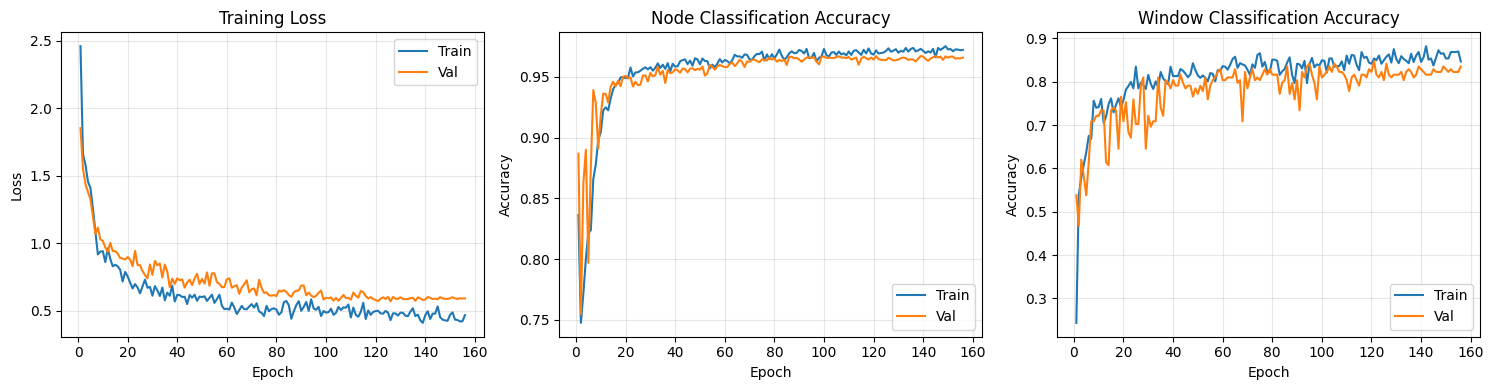

In [93]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs = [h["epoch"] for h in history]
# Loss plot
axes[0].plot(epochs, [h["train_loss"] for h in history], label="Train")
axes[0].plot(epochs, [h["val_loss"] for h in history], label="Val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
# Node accuracy
axes[1].plot(epochs, [h["train_node_acc"] for h in history], label="Train")
axes[1].plot(epochs, [h["val_node_acc"] for h in history], label="Val")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Node Classification Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
# Window accuracy
axes[2].plot(epochs, [h["train_window_acc"] for h in history], label="Train")
axes[2].plot(epochs, [h["val_window_acc"] for h in history], label="Val")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Accuracy")
axes[2].set_title("Window Classification Accuracy")
axes[2].legend()
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


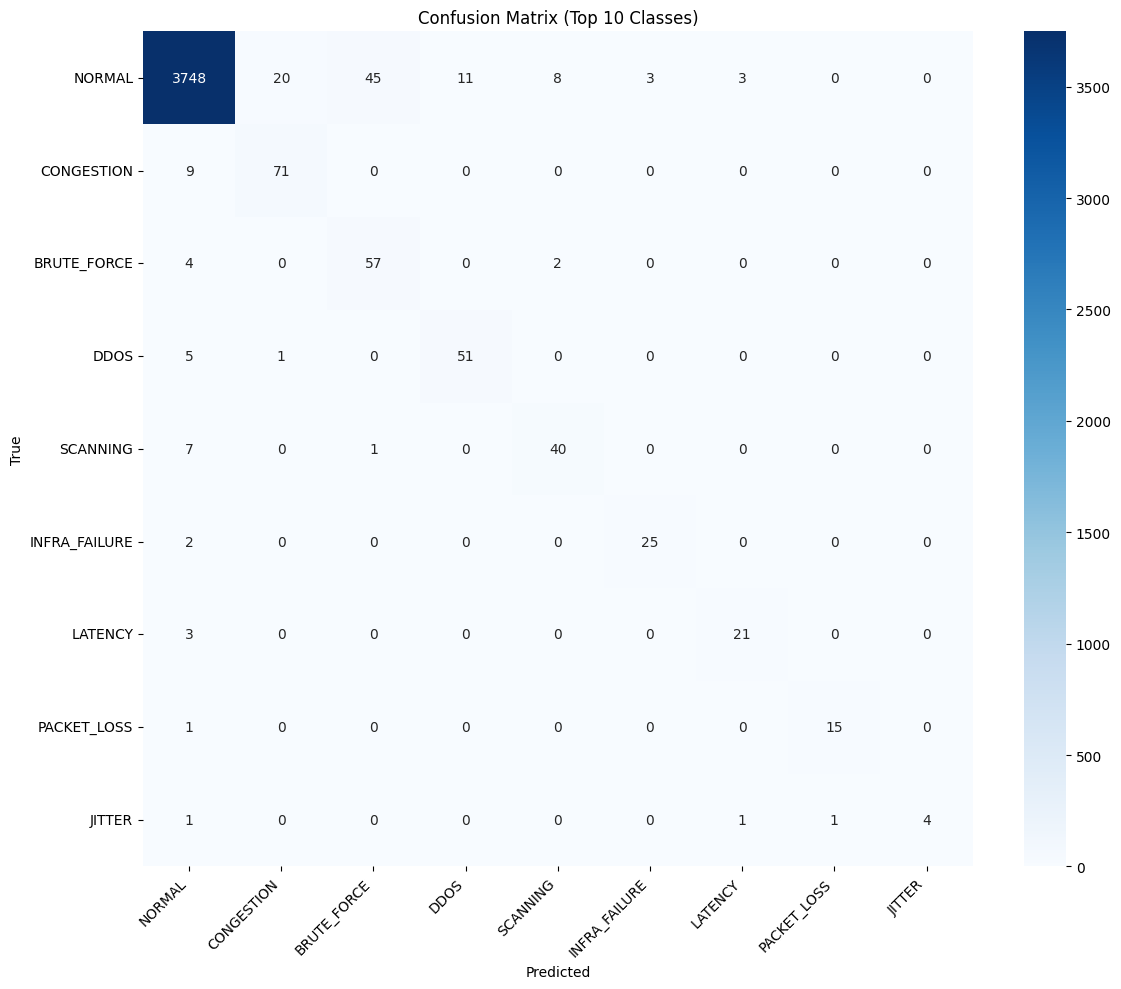

In [94]:
# Confusion Matrix for top classes
from collections import Counter
# Get top 10 most frequent classes
label_counts = Counter(test_metrics["labels"])
top_classes = [label for label, _ in label_counts.most_common(10)]
# Filter for top classes only
mask = np.isin(test_metrics["labels"], top_classes)
filtered_labels = test_metrics["labels"][mask]
filtered_preds = test_metrics["preds"][mask]
cm = confusion_matrix(filtered_labels, filtered_preds, labels=top_classes)
# Plot
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[dataset.index_to_label[i] for i in top_classes],
    yticklabels=[dataset.index_to_label[i] for i in top_classes],
    ax=ax
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (Top 10 Classes)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 6. Inference <a name="inference"></a>

Run inference on specific windows:

In [95]:
@torch.no_grad()
def predict_window(model, dataset, window_idx, device):
    """Predict for a single window."""
    model.eval()
    
    data = dataset[window_idx].to(device)
    data.x = data.x.unsqueeze(0)  # Add batch dim
    
    node_logits, window_logits = model(data)
    
    node_probs = F.softmax(node_logits, dim=-1)
    window_probs = F.softmax(window_logits, dim=-1)
    
    node_preds = node_probs.argmax(dim=-1)
    window_pred = window_probs.argmax(dim=-1).item()
    
    # Top-k predictions
    top_k = 3
    node_top_k = torch.topk(node_probs, k=min(top_k, node_probs.shape[-1]), dim=-1)
    window_top_k = torch.topk(window_probs[0], k=min(top_k, window_probs.shape[-1]))
    
    # Build result
    node_predictions = []
    for i, pred_idx in enumerate(node_preds.cpu().numpy()):
        node_predictions.append({
            "node_idx": i,
            "node_name": dataset.metadata["node_names"][i],
            "predicted_label": dataset.index_to_label[pred_idx],
            "predicted_idx": int(pred_idx),
            "confidence": float(node_probs[i, pred_idx]),
        })
    
    result = {
        "window_idx": window_idx,
        "window_prediction": {
            "label": dataset.index_to_label[window_pred],
            "idx": window_pred,
            "confidence": float(window_probs[0, window_pred]),
            "top_k": [
                {
                    "label": dataset.index_to_label[int(idx)],
                    "prob": float(prob),
                }
                for idx, prob in zip(
                    window_top_k.indices.cpu().numpy(),
                    window_top_k.values.cpu().numpy(),
                )
            ],
        },
        "node_predictions": node_predictions,
        "anomaly_detected": window_pred != 0,
        "affected_nodes": [
            p["node_name"] for p in node_predictions
            if p["predicted_idx"] != 0
        ],
    }
    
    return result
def print_prediction(result):
    """Pretty print prediction."""
    print(f"\n{'='*60}")
    print(f"Prediction for Window {result['window_idx']}")
    print(f"{'='*60}")
    
    win_pred = result["window_prediction"]
    print(f"\nWindow Prediction: {win_pred['label']} (confidence: {win_pred['confidence']:.4f})")
    print("Top-3 predictions:")
    for pred in win_pred["top_k"]:
        print(f"  - {pred['label']}: {pred['prob']:.4f}")
    
    if result["anomaly_detected"]:
        print(f"\nÃ¢ÂÂ Ã¯Â¸Â  ANOMALY DETECTED!")
        print(f"   Affected nodes: {', '.join(result['affected_nodes'])}")
    else:
        print(f"\nÃ¢ÂÂ System Normal")
    
    anomalous = [p for p in result["node_predictions"] if p["predicted_idx"] != 0]
    if anomalous:
        print(f"\nAnomalous nodes:")
        for node in anomalous[:10]:
            print(f"  {node['node_name']}: {node['predicted_label']} (conf: {node['confidence']:.4f})")
    else:
        print(f"\nNo anomalous nodes detected")
    
    print(f"{'='*60}")
# Test inference on a few windows
for idx in [0, 50, 100]:
    if idx < len(dataset):
        result = predict_window(model, dataset, idx, device)
        print_prediction(result)



Prediction for Window 0

Window Prediction: NORMAL (confidence: 0.2281)
Top-3 predictions:
  - NORMAL: 0.2281
  - JITTER: 0.1598
  - LATENCY: 0.1151

Ã¢ÂÂ System Normal

No anomalous nodes detected

Prediction for Window 50

Window Prediction: DDOS (confidence: 0.8643)
Top-3 predictions:
  - DDOS: 0.8643
  - NORMAL: 0.1332
  - BRUTE_FORCE: 0.0017

Ã¢ÂÂ Ã¯Â¸Â  ANOMALY DETECTED!
   Affected nodes: dc_web, h1_iot, h2_cam

Anomalous nodes:
  dc_web: DDOS (conf: 0.9987)
  h1_iot: DDOS (conf: 0.9981)
  h2_cam: DDOS (conf: 0.9981)

Prediction for Window 100

Window Prediction: CONGESTION (confidence: 0.9874)
Top-3 predictions:
  - CONGESTION: 0.9874
  - NORMAL: 0.0113
  - DDOS: 0.0013

Ã¢ÂÂ Ã¯Â¸Â  ANOMALY DETECTED!
   Affected nodes: dc_web, e1_pc1, e1_pc2

Anomalous nodes:
  dc_web: CONGESTION (conf: 0.9727)
  e1_pc1: CONGESTION (conf: 0.9586)
  e1_pc2: CONGESTION (conf: 0.9600)


# F1 Score by class visualization
fig, ax = plt.subplots(figsize=(14, 6))

# Get unique labels and their F1 scores properly aligned
unique_labels = sorted(set(test_metrics["labels"]))
precision, recall, f1, support = precision_recall_fscore_support(
    test_metrics["labels"], test_metrics["preds"], labels=unique_labels, average=None, zero_division=0
)

x_pos = np.arange(len(unique_labels))
f1_scores = list(f1)  # f1 is already aligned with unique_labels
label_names = [dataset.index_to_label.get(i, f"Class_{i}") for i in unique_labels]

colors = ["green" if f > 0.8 else "orange" if f > 0.5 else "red" for f in f1_scores]
bars = ax.bar(x_pos, f1_scores, color=colors, alpha=0.7)

ax.set_xticks(x_pos)
ax.set_xticklabels(label_names, rotation=45, ha="right")
ax.set_ylabel("F1 Score")
ax.set_title("Per-Class F1 Score on Test Set")
ax.axhline(y=0.8, color="g", linestyle="--", alpha=0.5, label="Good (>0.8)")
ax.axhline(y=0.5, color="r", linestyle="--", alpha=0.5, label="Poor (<0.5)")
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

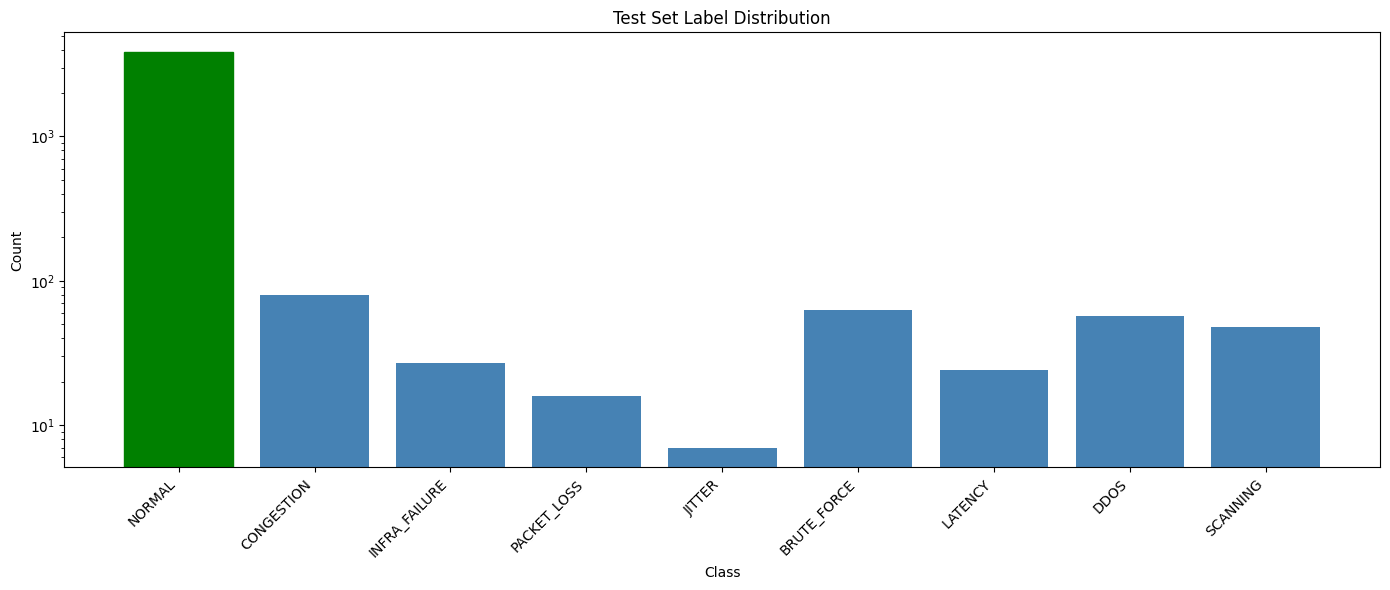


Class imbalance ratio:
  NORMAL: 1:1.0
  CONGESTION: 1:48.0
  INFRA_FAILURE: 1:142.1
  PACKET_LOSS: 1:239.9
  JITTER: 1:548.3
  BRUTE_FORCE: 1:60.9
  LATENCY: 1:159.9
  DDOS: 1:67.3
  SCANNING: 1:80.0


In [96]:
# Label distribution visualization
label_counts = Counter(test_metrics["labels"])
labels = [dataset.index_to_label[i] for i in label_counts.keys()]
counts = list(label_counts.values())
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(labels)), counts, color="steelblue")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.set_title("Test Set Label Distribution")
ax.set_yscale("log")
# Highlight NORMAL class
if "NORMAL" in labels:
    normal_idx = labels.index("NORMAL")
    bars[normal_idx].set_color("green")
plt.tight_layout()
plt.show()
print("\nClass imbalance ratio:")
normal_count = label_counts.get(dataset.label_to_index["NORMAL"], 1)
for label, count in zip(labels, counts):
    if count > 0:
        ratio = normal_count / count
        print(f"  {label}: 1:{ratio:.1f}")


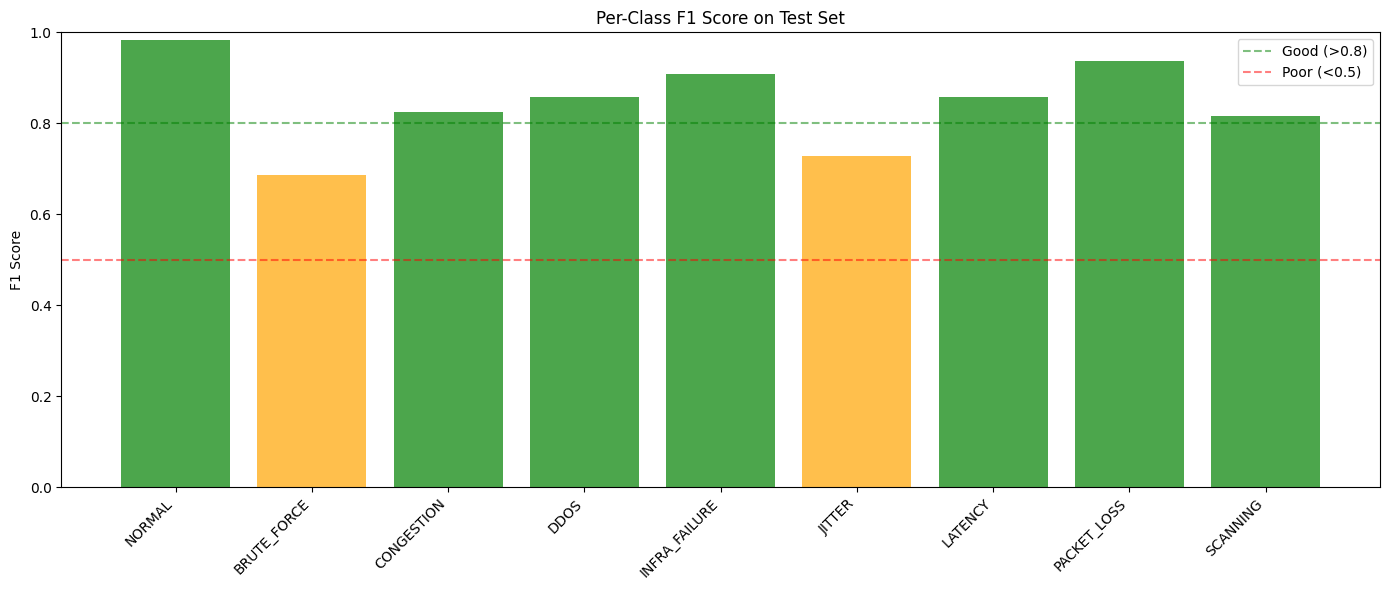

In [97]:
# F1 Score by class visualization
fig, ax = plt.subplots(figsize=(14, 6))
# Get unique labels and their F1 scores properly aligned
unique_labels = sorted(set(test_metrics["labels"]))
precision, recall, f1, support = precision_recall_fscore_support(
    test_metrics["labels"], test_metrics["preds"], labels=unique_labels, average=None, zero_division=0
)
x_pos = np.arange(len(unique_labels))
f1_scores = list(f1)  # f1 is already aligned with unique_labels positions
label_names = [dataset.index_to_label.get(i, f"Class_{i}") for i in unique_labels]
colors = ["green" if f > 0.8 else "orange" if f > 0.5 else "red" for f in f1_scores]
bars = ax.bar(x_pos, f1_scores, color=colors, alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels(label_names, rotation=45, ha="right")
ax.set_ylabel("F1 Score")
ax.set_title("Per-Class F1 Score on Test Set")
ax.axhline(y=0.8, color="g", linestyle="--", alpha=0.5, label="Good (>0.8)")
ax.axhline(y=0.5, color="r", linestyle="--", alpha=0.5, label="Poor (<0.5)")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


In [98]:
# Save model and results
import pickle
# Save model
torch.save({
    "model_state_dict": model.state_dict(),
    "config": CONFIG,
    "history": history,
    "test_metrics": {
        "loss": test_metrics["loss"],
        "node_acc": test_metrics["node_acc"],
        "window_acc": test_metrics["window_acc"],
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    },
}, "gnn_model_complete.pt")
# Save label mapping
with open("label_mapping.json", "w") as f:
    json.dump({
        "label_to_index": dataset.label_to_index,
        "index_to_label": dataset.index_to_label,
        "node_names": dataset.metadata["node_names"],
    }, f, indent=2)
print("Ã¢ÂÂ Model saved to: gnn_model_complete.pt")
print("Ã¢ÂÂ Label mapping saved to: label_mapping.json")
# Summary
print(f"\n{'='*60}")
print(f"Training Summary")
print(f"{'='*60}")
print(f"Model: TemporalGAT")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Epochs trained: {len(history)}")
print(f"\nBest validation loss: {best_val_loss:.4f}")
print(f"Test node accuracy: {test_metrics['node_acc']:.4f}")
print(f"Test window accuracy: {test_metrics['window_acc']:.4f}")
print(f"Test macro F1: {macro_f1:.4f}")
print(f"{'='*60}")


Ã¢ÂÂ Model saved to: gnn_model_complete.pt
Ã¢ÂÂ Label mapping saved to: label_mapping.json

Training Summary
Model: TemporalGAT
Parameters: 829,332
Epochs trained: 156

Best validation loss: 0.5682
Test node accuracy: 0.9692
Test window accuracy: 0.8562
Test macro F1: 0.8445
